# Blood Pressure Softmax Classification

## Load modules

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))

NumPy Version :2.0.2
TensorFlow Version :2.19.0
Matplotlib Version :3.10.0


## Input and Label

In [2]:
#Input(AGE, BMI) and Labels(0: 정상, 1: 주의, 2: 경고)
x_input = tf.constant([[25,22],[25,26],[25,30],[35,22],[35,26],[35,30],[45,22],[45,26],[45,30],[55,22],[55,26],[55,30],[65,22],[65,26],[65,30],[73,22],[73,26],[73,30]], dtype= tf.float32)
labels = tf.constant([[1,0,0],[0,1,0],[0,0,1],[1,0,0],[0,1,0],[1,0,0],[1,0,0],[1,0,0],[0,1,0],[1,0,0],[0,1,0],[0,0,1],[0,1,0],[0,0,1],[0,0,1],[0,1,0],[0,0,1],[0,0,1]], dtype= tf.float32)

## Min Max Scaler

In [3]:
x_input_org = x_input
x_min, x_max = np.min(x_input, axis=0), np.max(x_input, axis=0)
x_input = (x_input-x_min)/(x_max-x_min)

## Model 정의

In [4]:
model = tf.keras.models.Sequential([
  tf.keras.Input(shape=(2,)),
  tf.keras.layers.Dense(3, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

## Model compile

In [5]:
model.compile(optimizer= tf.keras.optimizers.SGD(learning_rate=0.1), loss='categorical_crossentropy', metrics=['accuracy'])

## 학습 (Training)

In [6]:
%%time
history = model.fit(x_input, labels, epochs=1000)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 601ms/step - accuracy: 0.5556 - loss: 1.0749
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5000 - loss: 1.0713
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5000 - loss: 1.0678
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5000 - loss: 1.0645
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5000 - loss: 1.0614
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5000 - loss: 1.0584
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5000 - loss: 1.0555
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5000 - loss: 1.0528
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4444 - loss: 1.0502
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4444 - loss: 1.0477
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4444 - loss: 1.0453
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy

## Plot

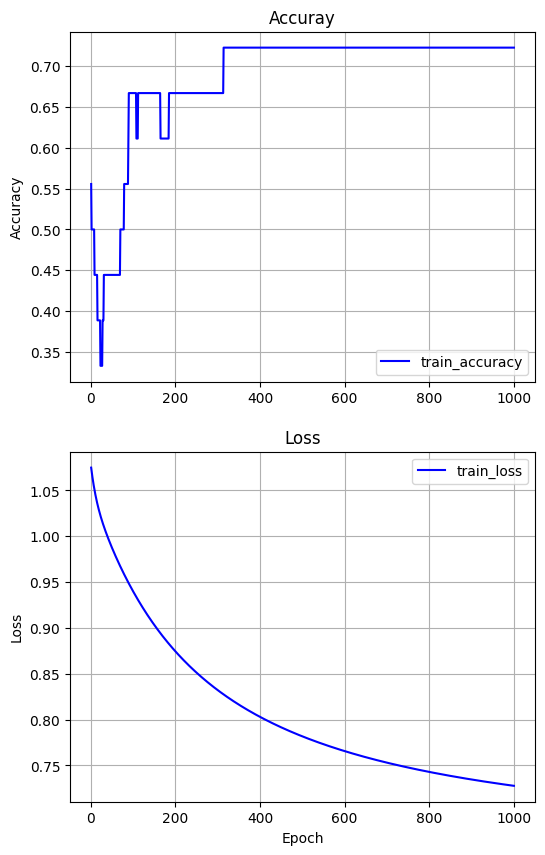

In [7]:
# accuray, loss 그래프 출력
loss = history.history['loss']
epochs = range(1, len(loss)+1)

plt.figure(figsize=(6, 10))
plt.subplot(2, 1, 1)
plt.title('Accuray')
plt.plot(epochs, history.history['accuracy'], 'b', label='train_accuracy')
plt.grid(True)
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.title('Loss')
plt.plot(epochs, history.history['loss'], 'b', label='train_loss')
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

## Training 결과 Test

In [8]:
H_x = model.predict(x_input)
for x,h,l in zip(x_input_org, H_x, labels):
  print("Age:{},BMI:{} [label:{}]=>class:{}: {}".format(x[0],x[1],np.argmax(l), np.argmax(h),h))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Age:25.0,BMI:22.0 [label:0]=>class:0: [0.785882   0.20423779 0.00988014]
Age:25.0,BMI:26.0 [label:1]=>class:0: [0.6032781  0.32507762 0.07164429]
Age:25.0,BMI:30.0 [label:2]=>class:2: [0.30872834 0.34493464 0.34633693]
Age:35.0,BMI:22.0 [label:0]=>class:0: [0.70473886 0.27478293 0.02047814]
Age:35.0,BMI:26.0 [label:1]=>class:0: [0.48009184 0.3881295  0.13177858]
Age:35.0,BMI:30.0 [label:0]=>class:2: [0.18978478 0.31812993 0.49208522]
Age:45.0,BMI:22.0 [label:0]=>class:0: [0.6052734  0.3540756  0.04065092]
Age:45.0,BMI:26.0 [label:0]=>class:1: [0.35120392 0.42598516 0.22281091]
Age:45.0,BMI:30.0 [label:1]=>class:2: [0.10517673 0.2645121  0.63031125]
Age:55.0,BMI:22.0 [label:0]=>class:0: [0.4919101  0.43173072 0.07635915]
Age:55.0,BMI:26.0 [label:1]=>class:1: [0.23331158 0.4245749  0.3421134 ]
Age:55.0,BMI:30.0 [label:2]=>class:2: [0.05369259 0.20259243 0.7437149 ]
Age:65.0,BMI:22.0 [label:1]=>class:1: [0.37375447 0.49214873 0.13409677]
Age:65.0,BMI:

## Predict

In [9]:
def predict(x):
  return model.predict((x-x_min)/(x_max-x_min))

In [10]:
x_test = tf.constant([[50.0, 25.0]], dtype= tf.float32)
H_x = predict(x_test)
print("Age : {}, BMI : {} => Class: {}".format(x_test[0,0],x_test[0,1],np.argmax(H_x[0])),H_x[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Age : 50.0, BMI : 25.0 => Class: 1 [0.35864702 0.44403896 0.19731404]
